In [1]:
#data set is in an old version of stata.  Will need library foreign to load it
library(foreign)
wagedata <- read.dta("WAGE1.DTA")

Warning message in read.dta("WAGE1.DTA"):
“cannot read factor labels from Stata 5 files”


In [2]:
#Examine data
head(wagedata)

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,⋯,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>
1,3.10,11,2,0,0,1,0,2,1,0,⋯,0,0,0,0,0,0,0,1.131402,4,0
2,3.24,12,22,2,0,1,1,3,1,0,⋯,0,0,1,0,0,0,1,1.175573,484,4
3,3.00,11,2,0,0,0,0,2,0,0,⋯,0,1,0,0,0,0,0,1.098612,4,0
4,6.00,8,44,28,0,0,1,0,1,0,⋯,0,0,0,0,0,1,0,1.791759,1936,784
5,5.30,12,7,2,0,0,1,1,0,0,⋯,0,0,0,0,0,0,0,1.667707,49,4
6,8.75,16,9,8,0,0,1,0,1,0,⋯,0,0,0,1,1,0,0,2.169054,81,64


In [3]:
#summarize wages
summary(wagedata[,"wage"])

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.530   3.330   4.650   5.896   6.880  24.980 

In [4]:
#summarize education, experience, and tenure
summary(wagedata[,"educ"])
summary(wagedata[,"exper"])

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   12.00   12.00   12.56   14.00   18.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    5.00   13.50   17.02   26.00   51.00 

In [5]:
#regress log wage on education
Reg1 <- lm(lwage~educ, data = wagedata)
#display full results of regression
summary(Reg1)


Call:
lm(formula = lwage ~ educ, data = wagedata)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.21158 -0.36393 -0.07263  0.29712  1.52339 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.583773   0.097336   5.998 3.74e-09 ***
educ        0.082744   0.007567  10.935  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4801 on 524 degrees of freedom
Multiple R-squared:  0.1858,	Adjusted R-squared:  0.1843 
F-statistic: 119.6 on 1 and 524 DF,  p-value: < 2.2e-16


In [6]:
#control for experience
Reg2 <- lm(lwage ~ educ + exper, data = wagedata)
#display full results of regression
summary(Reg2)


Call:
lm(formula = lwage ~ educ + exper, data = wagedata)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.05800 -0.30136 -0.04539  0.30601  1.44425 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.216854   0.108595   1.997   0.0464 *  
educ        0.097936   0.007622  12.848  < 2e-16 ***
exper       0.010347   0.001555   6.653 7.24e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4614 on 523 degrees of freedom
Multiple R-squared:  0.2493,	Adjusted R-squared:  0.2465 
F-statistic: 86.86 on 2 and 523 DF,  p-value: < 2.2e-16


In [7]:
#Allow a quadratic in experience
Reg3 <- lm(lwage ~ educ + exper + expersq, data = wagedata)
summary(Reg3)


Call:
lm(formula = lwage ~ educ + exper + expersq, data = wagedata)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.96387 -0.29375 -0.04009  0.29497  1.30216 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.1279975  0.1059323   1.208    0.227    
educ         0.0903658  0.0074680  12.100  < 2e-16 ***
exper        0.0410089  0.0051965   7.892 1.77e-14 ***
expersq     -0.0007136  0.0001158  -6.164 1.42e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4459 on 522 degrees of freedom
Multiple R-squared:  0.3003,	Adjusted R-squared:  0.2963 
F-statistic: 74.67 on 3 and 522 DF,  p-value: < 2.2e-16


In [8]:
#control for gender
Reg4<- lm(lwage ~ educ + exper + expersq + female, data = wagedata)
summary(Reg4)


Call:
lm(formula = lwage ~ educ + exper + expersq + female, data = wagedata)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.80836 -0.27728 -0.01813  0.25637  1.23896 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.3904830  0.1022096   3.820 0.000149 ***
educ         0.0841361  0.0069568  12.094  < 2e-16 ***
exper        0.0389100  0.0048235   8.067 5.00e-15 ***
expersq     -0.0006860  0.0001074  -6.389 3.71e-10 ***
female      -0.3371868  0.0363214  -9.283  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4134 on 521 degrees of freedom
Multiple R-squared:  0.3996,	Adjusted R-squared:  0.395 
F-statistic: 86.69 on 4 and 521 DF,  p-value: < 2.2e-16


In [9]:
#In these data, being non-white is not strongly correlated with wages.  What happens when we add it as a control?
Reg5<- lm(lwage ~ educ + exper + expersq + female + nonwhite, data = wagedata)
summary(Reg5)


Call:
lm(formula = lwage ~ educ + exper + expersq + female + nonwhite, 
    data = wagedata)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.81048 -0.27438 -0.01685  0.25408  1.23803 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.3954016  0.1032190   3.831 0.000143 ***
educ         0.0839129  0.0069907  12.004  < 2e-16 ***
exper        0.0389529  0.0048291   8.066 5.03e-15 ***
expersq     -0.0006872  0.0001075  -6.391 3.66e-10 ***
female      -0.3374241  0.0363579  -9.281  < 2e-16 ***
nonwhite    -0.0213127  0.0596998  -0.357 0.721239    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4138 on 520 degrees of freedom
Multiple R-squared:  0.3997,	Adjusted R-squared:  0.394 
F-statistic: 69.26 on 5 and 520 DF,  p-value: < 2.2e-16


In [10]:
# add in tenure.  Tenure relates to wages but not to education
#regress log wage on education
Reg1 <- lm(lwage~educ, data = wagedata)
#display full results of regression
summary(Reg1)
RegT<- lm(lwage~tenure, data = wagedata)
summary(RegT)
#how do coefficient and errors change when we control for tenure at the job?
Reg6 <- lm(lwage ~ educ + tenure, data = wagedata)
summary(Reg6)


Call:
lm(formula = lwage ~ educ, data = wagedata)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.21158 -0.36393 -0.07263  0.29712  1.52339 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.583773   0.097336   5.998 3.74e-09 ***
educ        0.082744   0.007567  10.935  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4801 on 524 degrees of freedom
Multiple R-squared:  0.1858,	Adjusted R-squared:  0.1843 
F-statistic: 119.6 on 1 and 524 DF,  p-value: < 2.2e-16



Call:
lm(formula = lwage ~ tenure, data = wagedata)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.15984 -0.38530 -0.04478  0.32696  1.46072 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1.501007   0.026866  55.870  < 2e-16 ***
tenure      0.023951   0.003039   7.881 1.89e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5031 on 524 degrees of freedom
Multiple R-squared:  0.106,	Adjusted R-squared:  0.1043 
F-statistic: 62.11 on 1 and 524 DF,  p-value: 1.89e-14



Call:
lm(formula = lwage ~ educ + tenure, data = wagedata)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.10350 -0.29287 -0.04081  0.28672  1.44967 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.404474   0.091696   4.411 1.25e-05 ***
educ        0.086528   0.006991  12.377  < 2e-16 ***
tenure      0.025814   0.002680   9.634  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4428 on 523 degrees of freedom
Multiple R-squared:  0.3085,	Adjusted R-squared:  0.3059 
F-statistic: 116.7 on 2 and 523 DF,  p-value: < 2.2e-16


In [11]:
#What about when you add a strongly correlated variable?

Reg7 <- lm(lwage ~ profocc, data = wagedata)
summary(Reg7)
Reg8 <- lm(lwage~  profocc + educ, data = wagedata)
summary(Reg8)



Call:
lm(formula = lwage ~ profocc, data = wagedata)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.07819 -0.34470 -0.05701  0.32969  1.28431 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.44331    0.02611   55.28   <2e-16 ***
profocc      0.49046    0.04310   11.38   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4764 on 524 degrees of freedom
Multiple R-squared:  0.1982,	Adjusted R-squared:  0.1966 
F-statistic: 129.5 on 1 and 524 DF,  p-value: < 2.2e-16



Call:
lm(formula = lwage ~ profocc + educ, data = wagedata)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.10405 -0.30459 -0.04389  0.30578  1.29300 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.827195   0.099273   8.333 7.00e-16 ***
profocc     0.337920   0.047862   7.060 5.31e-12 ***
educ        0.053498   0.008339   6.416 3.14e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4592 on 523 degrees of freedom
Multiple R-squared:  0.2567,	Adjusted R-squared:  0.2538 
F-statistic: 90.29 on 2 and 523 DF,  p-value: < 2.2e-16


In [12]:
#remind correlations between education and experience
Reg1 <- lm(lwage~educ, data = wagedata)
summary(Reg1)
Reg2 <- lm(lwage~educ + exper, data = wagedata)
summary(Reg2)


Call:
lm(formula = lwage ~ educ, data = wagedata)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.21158 -0.36393 -0.07263  0.29712  1.52339 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.583773   0.097336   5.998 3.74e-09 ***
educ        0.082744   0.007567  10.935  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4801 on 524 degrees of freedom
Multiple R-squared:  0.1858,	Adjusted R-squared:  0.1843 
F-statistic: 119.6 on 1 and 524 DF,  p-value: < 2.2e-16



Call:
lm(formula = lwage ~ educ + exper, data = wagedata)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.05800 -0.30136 -0.04539  0.30601  1.44425 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.216854   0.108595   1.997   0.0464 *  
educ        0.097936   0.007622  12.848  < 2e-16 ***
exper       0.010347   0.001555   6.653 7.24e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4614 on 523 degrees of freedom
Multiple R-squared:  0.2493,	Adjusted R-squared:  0.2465 
F-statistic: 86.86 on 2 and 523 DF,  p-value: < 2.2e-16


In [13]:
#predict education using exper
#regress education on experience
Reg3 <- lm(educ ~ exper, data = wagedata)
summary(Reg3)
#predict fitted values
wagedata[,"educ_hat"]<-predict(Reg3,wagedata)
head(wagedata[,c("educ","exper","educ_hat")])



Call:
lm(formula = educ ~ exper, data = wagedata)

Residuals:
    Min      1Q  Median      3Q     Max 
-12.258  -1.358  -0.236   1.721   6.170 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 13.602708   0.185024  73.519  < 2e-16 ***
exper       -0.061113   0.008504  -7.187  2.3e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.644 on 524 degrees of freedom
Multiple R-squared:  0.08973,	Adjusted R-squared:  0.08799 
F-statistic: 51.65 on 1 and 524 DF,  p-value: 2.295e-12


,educ,exper,educ_hat
,<int>,<int>,<dbl>
1,11,2,13.48048
2,12,22,12.25822
3,11,2,13.48048
4,8,44,10.91373
5,12,7,13.17492
6,16,9,13.05269


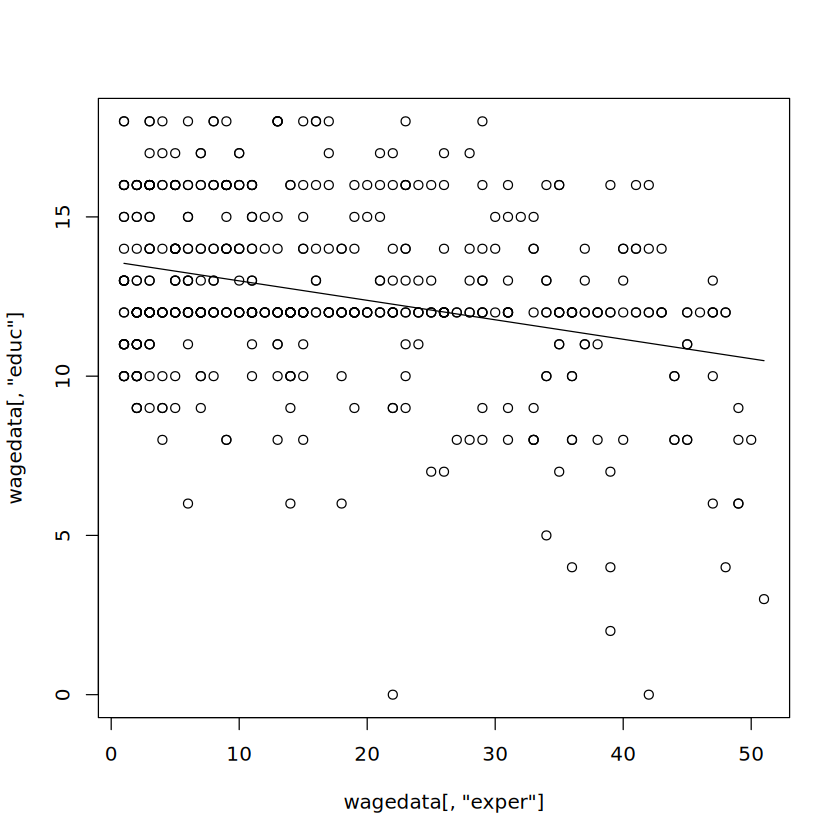

In [14]:
#plot fitted values
plot(wagedata[,"exper"], wagedata[,"educ"])
lines(wagedata[,"exper"], wagedata[,"educ_hat"])

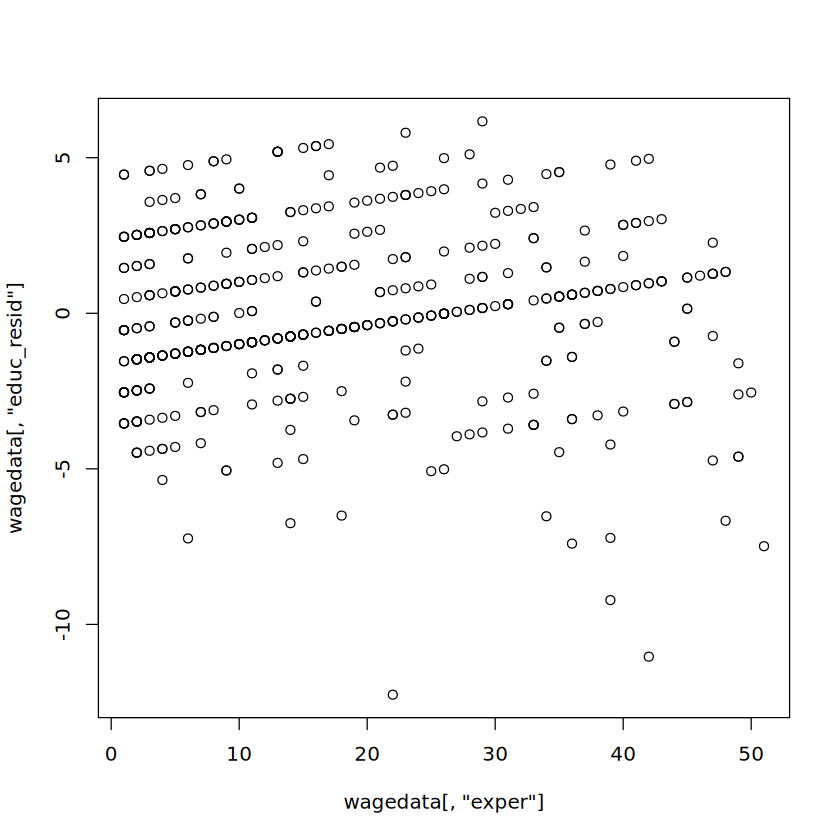

In [15]:
#predict residuals
wagedata[,"educ_resid"]<-wagedata[,"educ"]-wagedata[,"educ_hat"]
#plot residuals
plot(wagedata[,"exper"],wagedata[,"educ_resid"])

In [16]:
#regress log wages on residuals
Reg4<-lm(lwage~educ_resid, data = wagedata)
summary(Reg4)


Call:
lm(formula = lwage ~ educ_resid, data = wagedata)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.11914 -0.31994 -0.07051  0.29586  1.47471 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1.623268   0.020264   80.10   <2e-16 ***
educ_resid  0.097936   0.007678   12.76   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4648 on 524 degrees of freedom
Multiple R-squared:  0.2369,	Adjusted R-squared:  0.2355 
F-statistic: 162.7 on 1 and 524 DF,  p-value: < 2.2e-16


In [17]:
#What about multicollinear variables
#define variable notfemale = 1-female
wagedata[,"notfemale"] <- 1-wagedata[,"female"]
#regress log wages on education, notfemale, and female
Reg9 <- lm(lwage ~ educ + notfemale + female, data = wagedata)
summary(Reg9)


Call:
lm(formula = lwage ~ educ + notfemale + female, data = wagedata)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.02672 -0.27470 -0.03731  0.26219  1.34738 

Coefficients: (1 not defined because of singularities)
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.465404   0.091227   5.102 4.72e-07 ***
educ        0.077203   0.007047  10.955  < 2e-16 ***
notfemale   0.360865   0.039024   9.247  < 2e-16 ***
female            NA         NA      NA       NA    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4455 on 523 degrees of freedom
Multiple R-squared:  0.3002,	Adjusted R-squared:  0.2975 
F-statistic: 112.2 on 2 and 523 DF,  p-value: < 2.2e-16


In [18]:
#what about more complicated multicollinearity?
#exper in this data set is age + educ + 6.  What happens if we run our regressions controlling for age, educ, and exper?
#define age in the data
wagedata[,"age"]<-wagedata[,"exper"]+wagedata[,"educ"]+6
Reg10 <-lm(lwage ~ educ + exper + age, data = wagedata)
summary(Reg10)


Call:
lm(formula = lwage ~ educ + exper + age, data = wagedata)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.05800 -0.30136 -0.04539  0.30601  1.44425 

Coefficients: (1 not defined because of singularities)
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.216854   0.108595   1.997   0.0464 *  
educ        0.097936   0.007622  12.848  < 2e-16 ***
exper       0.010347   0.001555   6.653 7.24e-11 ***
age               NA         NA      NA       NA    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4614 on 523 degrees of freedom
Multiple R-squared:  0.2493,	Adjusted R-squared:  0.2465 
F-statistic: 86.86 on 2 and 523 DF,  p-value: < 2.2e-16
